<div style="text-align: center;">
  <img src="02_src/bioDYM_Logo.png" alt="BioDYM Logo" width="600"/>
</div>

# BioDYM - Material Flow Analysis Framework

**A streamlined framework for dynamic Material Flow Analysis of bio-based systems**

---

### 👥 Authors
**Johannes Scholz** • Technical University of Berlin
**Lukas Hoppe** • Technical University of Berlin
**Albrecht Fritze** • Technical University of Berlin
**Vera Susanne Rotter** • Technical University of Berlin
*Contributing authors and collaborators listed in CONTRIBUTORS.md*

### 📄 License
This project is licensed under the **MIT License** - see the [LICENSE](LICENSE) file for details.
Built on the [ODYM Framework](https://github.com/IndEcol/ODYM) (Pauliuk & Heeren, 2020)

---

### 📖 Table of Contents

* [0. Introduction](#0.-Introduction)
  * [🚀 Quick Start Guide](#🚀-Quick-Start-Guide)
* [1. Setup and Data Loading](#1.-Setup-and-Data-Loading)
  * [1.1 Environment Setup](#1.1-Environment-Setup)
  * [1.2 Data Input Configuration](#1.2-Data-Input-Configuration)
  * [1.3 System Configuration Extraction](#1.3-System-Configuration-Extraction)
* [2. Calculation & Mass Balance](#2.-Calculation-&-Mass-Balance)
  * [2.1 Model Initialization & Calculation](#2.1-Model-Initialization-&-Calculation)
  * [2.2 Data Validation Summary](#2.2-Data-Validation-Summary)
  * [2.3 Mass Balance Verification](#2.3-Mass-Balance-Verification)
  * [2.4 System Flow Diagram (Graphviz)](#2.4-System-Flow-Diagram-(Graphviz))
  * [2.5 Flow Composition Validation](#2.5-Flow-Composition-Validation)
* [3. Visualization](#3.-Visualization)
  * [3.1 Sankey Diagrams](#3.1-Sankey-Diagrams)
  * [3.2 Additional Visualizations](#3.2-Additional-Visualizations)
* [4. Scenario & Uncertainty Manager](#4.-Scenario-&-Uncertainty-Manager)
  * [4.1 Scenario Analysis & Comparison](#4.1-Scenario-Analysis-&-Comparison)
  * [4.2 Monte Carlo Analysis](#4.2-Monte-Carlo-Analysis)
* [5. Data Export](#5.-Data-Export)
  * [5.1 KPI Dashboard and Export](#5.1-KPI-Dashboard-and-Export)

---

## 📋 Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Mass Balance** - Execute MFA analysis and verify mass conservation
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario & Uncertainty Analysis** - Compare scenarios and run Monte Carlo simulations
5. **Data Export** - Save results and generate documentation

---

# 0. Introduction

## 🚀 Quick Start Guide

**Welcome to BioDYM!** This notebook performs a complete Material Flow Analysis from data loading to results export.

### Getting Started

1. **Required Input**: Only the **Excel file path** needs to be set (see Section 1.2 below)
2. **Full Documentation**: See [README.md](README.md) for detailed setup instructions
3. **Example Data**: Template files are provided in `01_data/01_input/`

### Prerequisites
- Python 3.12+ with dependencies installed (`uv sync`)
- Excel input file following the BioDYM template structure

### Support
- **Documentation**: `05_docs/` folder
- **Issues**: [GitHub Issues](https://github.com/your-repo/BioDYM/issues)

### 🔧 Debug Mode
Set `DEBUG_MODE = True` below to see detailed technical output during data loading and calculation.
Default: `False` (clean, user-friendly output)

In [1]:
DEBUG_MODE = False  # Set to True for detailed technical output

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [2]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [3]:
# Suppress openpyxl data validation warnings (harmless, caused by Excel dropdown rules)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [4]:
# Add BioDYM modules to path to make them importable
src_path = os.path.join(os.getcwd(), "02_src")
sys.path.insert(0, src_path)

In [5]:
# Add ODYM framework to path. ODYM is a foundational library for this project.
project_root = os.getcwd()
odym_path = os.path.join(
    project_root, "06_framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [6]:
# Add bioDYM add-on to path for custom extensions.
biodym_addon_path = os.path.join(
    project_root, "06_framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [7]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    import plotting
    import ODYM_Classes as msc
    from plotting.composition import plot_flow_composition
    from reporting import kpi_dashboard

    # Import standard icons
    from constants import (
        Icons,
        format_header,
        format_step,
        format_success,
        format_error,
        format_file_path,
    )

    print(f"{Icons.SUCCESS} BioDYM modules imported successfully")
except ImportError as e:
    print(f"{Icons.ERROR} Import error: {e}")
    print(f"{Icons.ERROR} A required module could not be found.")
    print(
        f"{Icons.INFO} Please ensure all dependencies are installed by running: uv sync"
    )
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [8]:
# Set up plotting
plt.style.use("default")
print(f"{Icons.VISUALIZATION} Plotting environment ready")

📊 Plotting environment ready


In [9]:
# Initialize Plotly widgets to prevent empty plot issues
# This forces the widget communication channel to be established early
print(f"{Icons.CONFIGURATION} Initializing interactive widget system...")
import time
from ipywidgets import IntSlider

⚙️ Initializing interactive widget system...


In [10]:
try:
    # Create dummy widgets to initialize the comm channel
    _dummy_fig = go.FigureWidget()
    _dummy_slider = IntSlider()
    time.sleep(0.5)  # Allow widget registration to complete
    del _dummy_fig, _dummy_slider
    print(f"{Icons.SUCCESS} Widget system initialized successfully")
except Exception as e:
    print(f"{Icons.WARNING} Widget initialization had issues: {e}")
    print(f"{Icons.INFO} Plots may take longer on first render")

✅ Widget system initialized successfully


## 1.2 Data Input Configuration

⚠️ **IMPORTANT**: Set your Excel file path below - this is the only required change to run the analysis!

In [11]:
input_file = "01_data/01_input/251118_BioDYM_ODYM_Reifen.xlsm"
print(format_file_path(input_file))
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

  📁 Loading: [01_data/01_input/251118_BioDYM_ODYM_Reifen.xlsm]


## 1.3 System Configuration Extraction

In [12]:
print(format_header("EXTRACTING CONFIGURATION FROM EXCEL"))


EXTRACTING CONFIGURATION FROM EXCEL



In [13]:
# Load the full dataset once. This will be passed to functions that need it.
# NOTE: Uses decimal=',' for European standard (comma as decimal separator)
# See 05_docs/DECIMAL_SEPARATOR_GUIDE.md for details
input_data = pd.read_excel(
    input_file,
    sheet_name=None,
    header=0,
    engine="openpyxl",
    na_values=["N.A.", "NA", "n/a"],
    decimal=",",
)
print(format_success(f"Excel file loaded: {len(input_data)} sheets"))

✅ Excel file loaded: 20 sheets


In [14]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print(format_success("Configuration object loaded."))

   🗑️  Temp file cleaned up: C:\Users\Johannes\AppData\Local\Temp\BioDYM_temp_eifiryi1.xlsm
   🗑️  Temp file cleaned up: C:\Users\Johannes\AppData\Local\Temp\BioDYM_temp_rar3ygio.xlsm
[OK] Found configuration sheet: '0_Configuration'
[OK] Loaded 3 elements from configuration: ['material', 'DM', 'CC']
   |-- E2 (DM) is expressed as % of material
   |-- E3 (CC) is expressed as % of DM
[OK] Loaded 1 regions from configuration: ['Case_Study_Region']
[OK] Loaded 4 goods from configuration: ['Raw Material', 'Processed Product', 'Product', 'Waste']
[OK] Loaded 4 process types from configuration: ['Biomass Production', 'Biomass Processing', 'Use-Phase', 'EoL-Phase']
✅ Configuration object loaded.


In [15]:
# Phase 1b: Extract dimension lists from config
def get_config_list(config_obj, attribute_name, default=None):
    """Helper to extract comma-separated lists from config object."""
    if hasattr(config_obj, attribute_name):
        value = getattr(config_obj, attribute_name)
        if value and pd.notna(value):
            return [item.strip() for item in str(value).split(",") if item.strip()]
    return default

In [16]:
regions = get_config_list(config_obj, "Regions", ["Case_Study_Region"])
goods = get_config_list(config_obj, "Goods", None)
materials = get_config_list(config_obj, "Materials", None)
processes = get_config_list(config_obj, "Process_Types", None)

In [17]:
print(f"{Icons.VISUALIZATION} Dimensions loaded from configuration:")
print(f"   {Icons.ARROW} Regions: {regions}")
if materials:
    print(f"   - Materials: {materials}")
if goods:
    print(f"   - Goods: {goods}")
if processes:
    print(f"   - Process Types: {processes}")

📊 Dimensions loaded from configuration:
   → Regions: ['Case_Study_Region']
   - Goods: ['Raw Material', 'Processed Product', 'Product', 'Waste']
   - Process Types: ['Biomass Production', 'Biomass Processing', 'Use-Phase', 'EoL-Phase']


In [18]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    # Try different possible element attribute names
    if hasattr(config_obj, "Elements"):
        elements = [elem.strip() for elem in config_obj.Elements.split(",")]
    elif hasattr(config_obj, "Elements_comma_separated"):
        elements = [
            elem.strip() for elem in config_obj.Elements_comma_separated.split(",")
        ]
    elif hasattr(config_obj, "Element_list"):
        elements = [elem.strip() for elem in config_obj.Element_list.split(",")]
    else:
        raise AttributeError("No Elements attribute found in config object")
except Exception as e:
    print(
        f"{Icons.WARNING} Could not get time/elements from config object: {e}. Falling back to data-driven values."
    )
    flow_data = input_data["1_2_Data_Flows"]
    # Fix: Use correct column name 'Flow_Data_Year' instead of 'Year_Flow'
    years = sorted(flow_data["Flow_Data_Year"].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ["material", "WC", "DM", "CC"]

In [19]:
# Display final configuration summary
run_scenario = getattr(config_obj, "Run_Scenario_Analysis", False)
selected_scenario = getattr(
    config_obj,
    "Selected_Scenario_Name 1",
    getattr(config_obj, "Selected_Scenario_Name", "N/A"),
)

In [20]:
print(f"\n-- Configuration Summary --")
print(f"{Icons.TIME} Time range: {start_year} - {end_year}")
print(f"{Icons.ELEMENT} Elements: {elements}")
print(
    f"{Icons.MONTE_CARLO} Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}"
)
print(
    f"{Icons.DSM} DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}"
)
print(
    f"{Icons.FOMP} FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}"
)
print(
    f"{Icons.SCENARIO} Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}"
)
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 2007 - 2023
🧪 Elements: ['material', 'DM', 'CC']
🎲 Monte Carlo: Disabled
🏗️ DSM Calculation: Enabled
🌱 FOMP Calculation: Disabled
🎭 Scenario Analysis: Enabled
   -> Selected Scenario: 'N/A'


# 2. Calculation & Mass Balance

In [21]:
# ## 2.1 Model Initialization & Calculation
print(format_header("RUNNING BASELINE MFA CALCULATION"))


RUNNING BASELINE MFA CALCULATION



In [22]:
print(format_step(Icons.SYSTEM, "2.1", "Setting up model scope..."))
model_classification, index_table = system_setup.define_model_scope(
    start_year, end_year, elements, regions, goods, materials, processes
)

  🔧 [2.1] Setting up model scope...


### ODYM System Index Table

The IndexTable defines all dimensions used in the MFA system following ODYM conventions.

In [23]:
index_table

,Description,Dimension,Classification,IndexLetter
Aspect,,,,
Time,"Model aspect ""time""",Time,<ODYM_Classes.Classification object at 0x00000...,t
Element,"Model aspect ""Element""",Element,<ODYM_Classes.Classification object at 0x00000...,e


In [24]:
print(format_step(Icons.SYSTEM, "2.2", "Initializing MFA system..."))
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

  🔧 [2.2] Initializing MFA system...


In [25]:
print(format_step(Icons.DATA_LOADING, "2.3", "Loading processes and data..."))
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(
    mfa_system_base, input_data, data_loader, debug_mode=DEBUG_MODE
)

  📥 [2.3] Loading processes and data...
   → Process 8 has initial stock - automatically creating stock objects


In [26]:
print(format_step(Icons.DATA_LOADING, "2.4", "Defining flows and parameters..."))
mfa_system_configured, _, flow_tc_map, process_logic_map = (
    system_setup.define_flows_and_parameters(
        mfa_system_base, all_excel_data, debug_mode=DEBUG_MODE
    )
)

  📥 [2.4] Defining flows and parameters...
--> Loading initial stock parameters from sheet '2_4_Initial_Stock'...
  -> Element parameter mapping: {'DM': 'IS_E2[%]', 'CC': 'IS_E3[%]'}
  -> Loaded initial stock config for Process 8
--> Successfully loaded initial stock configurations for 1 process(es).
--> Applying initial stock values...
  -> Set initial stock for Process 8: 1000000.0 Mg material
--> Initial stock values applied.
--> Processing initial stock outflows...
    -> Created flow F_8_9_stock (values will be set during solver)
    -> Created flow F_8_10_stock (values will be set during solver)
  -> Created 2 outflow flows for Process 8
--> Initial stock flow values initialized.
--> Initial stock outflows processed.


c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\02_src\engine\initial_stock_engine.py:151: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\02_src\engine\initial_stock_engine.py:178: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [27]:
print(
    format_step(
        Icons.CONFIGURATION, "2.5", "Loading model parameters (TCs, DSM, FOMP)..."
    )
)

  ⚙️ [2.5] Loading model parameters (TCs, DSM, FOMP)...


In [28]:
# Centralized call to the new, unified TC loader
time_vector = mfa_system_configured.IndexTable.Classification["Time"].Items
elements_list = mfa_system_configured.Elements
tc_params = data_loader.load_tc_parameters(
    all_excel_data, elements_list, time_vector, debug_mode=DEBUG_MODE
)
mfa_system_configured.ParameterDict.update(
    tc_params
)  # Add the new TC params to the system

   ✓ Loaded 20 transfer coefficients (6 static, 0 dynamic)


In [29]:
# Load other special model parameters
dsm_params = data_loader.load_dsm_parameters(all_excel_data, debug_mode=DEBUG_MODE)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(
        all_excel_data, debug_mode=DEBUG_MODE
    )
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(
    all_excel_data, debug_mode=DEBUG_MODE
)

In [30]:
print(format_success("All parameters loaded and configured."))

✅ All parameters loaded and configured.


In [31]:
print(format_step(Icons.CALCULATION, "2.6", "Running baseline calculation..."))
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(
    mfa_system_configured,
    dsm_params,
    fomp_params,
    config_obj,
    flow_tc_map=flow_tc_map,
    process_logic_map=process_logic_map,
)
print(format_success("Baseline calculation completed successfully!"))

  🧮 [2.6] Running baseline calculation...
[DSM DEBUG] Iteration 0: Process 8, Inflows: ['F_07_08', 'F_11_08'], Total Inflow Sum: 15602182.85, Ready: True
=== DSM DEBUG for Process 8 ===

--- Processing Category 1 (Standarfahrer) ---
Inflow category 1: [194463.    782370.084 193200.    197820.    219660.   ]... (first 5 years)

--- Processing Category 2 (Vielfahrer) ---
Inflow category 2: [ 64821.    260790.028  64400.     65940.     73220.   ]... (first 5 years)

--- Processing Category 3 (Wenigfahrer) ---
Inflow category 3: [ 64821.    260790.028  64400.     65940.     73220.   ]... (first 5 years)

--- Initial Stock Processing ---

--- Final Results Summary ---
Total outflow from inflows: 4269924.720513646
Total outflow from initial stock: 946144.6951030291
Total outflow material: 5216069.415616676
Total stock accumulated from inflows: 35416607.180720724
=== END DSM DEBUG for Process 8 ===

✅ DSM validation passed for process 8
[DSM DEBUG] Iteration 1: Process 8, Inflows: ['F_07_08',

## 2.2 Data Validation Summary

### 📋 Summary of Loaded Data

In [32]:
print(format_header("DATA VALIDATION SUMMARY", level=2))


DATA VALIDATION SUMMARY



In [33]:
# Count loaded items
num_processes = len(mfa_system_configured.ProcessList)
num_flows = len(mfa_system_configured.FlowDict)
num_stocks = len([k for k in mfa_system_configured.StockDict.keys()])
num_elements = len(elements)
time_span = end_year - start_year + 1

In [34]:
# Count parameters
num_static_tcs = sum(
    1
    for p in mfa_system_configured.ParameterDict.values()
    if "TC" in p.Name and np.isscalar(p.Values)
)
num_dynamic_tcs = sum(
    1
    for p in mfa_system_configured.ParameterDict.values()
    if "TC" in p.Name and isinstance(p.Values, np.ndarray)
)
num_dsm_processes = len(dsm_params) if dsm_params else 0
num_fomp_processes = len(fomp_params) if fomp_params else 0

In [35]:
# Display summary
print("\n📊 Configuration & Scope")
print(f"  ✅ Time range: {start_year}-{end_year} ({time_span} years)")
print(f"  ✅ Elements: {num_elements} defined ({', '.join(elements)})")
print(f"  ✅ Regions: {len(regions)} ({', '.join(regions)})")


📊 Configuration & Scope
  ✅ Time range: 2007-2023 (17 years)
  ✅ Elements: 3 defined (material, DM, CC)
  ✅ Regions: 1 (Case_Study_Region)


In [36]:
print("\n🏗️  System Structure")
print(f"  ✅ Processes: {num_processes} loaded")
print(f"  ✅ Flows: {num_flows} defined")
print(f"  ✅ Stocks: {num_stocks} configured")


🏗️  System Structure
  ✅ Processes: 20 loaded
  ✅ Flows: 22 defined
  ✅ Stocks: 4 configured


In [37]:
print("\n⚙️  Parameters")
print(f"  ✅ Transfer Coefficients:")
print(f"     • Static TCs: {num_static_tcs}")
print(f"     • Dynamic TCs: {num_dynamic_tcs}")
if num_dsm_processes > 0:
    print(f"  ✅ DSM Processes: {num_dsm_processes} configured")
else:
    print(f"  ⚠️  DSM Processes: None configured")
if num_fomp_processes > 0:
    print(f"  ✅ FOMP Processes: {num_fomp_processes} configured")
else:
    print(f"  ⚠️  FOMP Processes: None configured")


⚙️  Parameters
  ✅ Transfer Coefficients:
     • Static TCs: 20
     • Dynamic TCs: 0
  ✅ DSM Processes: 1 configured
  ⚠️  FOMP Processes: None configured


In [38]:
# Check for warnings
warnings_found = []
if num_dsm_processes == 0 and config_obj.RUN_DSM_CALCULATION:
    warnings_found.append("DSM calculation enabled but no processes configured")
if num_fomp_processes == 0 and config_obj.RUN_FOMP_CALCULATION:
    warnings_found.append("FOMP calculation enabled but no processes configured")

In [39]:
# Overall status
print("\n📍 Overall Status")
if len(warnings_found) == 0:
    print("  🟢 ALL SYSTEMS GO - No warnings detected")
    print("  ✅ All required data loaded successfully")
else:
    print(f"  🟡 READY WITH {len(warnings_found)} WARNING(S)")
    for warning in warnings_found:
        print(f"     ⚠️  {warning}")
    print("  ✅ Analysis can proceed (warnings are non-critical)")


📍 Overall Status
  🟢 ALL SYSTEMS GO - No warnings detected
  ✅ All required data loaded successfully


In [40]:
print()

## 2.3 Mass Balance Verification

In [41]:
print(format_header("MASS BALANCE VERIFICATION (BASELINE)", level=2))
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)


MASS BALANCE VERIFICATION (BASELINE)



c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\02_src\plotting\export_publication.py:188: UserWarning:

Unknown size preset 'large'. Using current size.



✅ Exported PNG: 01_data\02_output\figures\mass_balance_total_20251118_205635.png (845.3 KB, 400 DPI)
✅ Exported PDF: 01_data\02_output\figures\mass_balance_total_20251118_205635.pdf (57.5 KB, 400 DPI)

✅ Figure exported: 01_data\02_output\figures\mass_balance_total_20251118_205635.png, 01_data\02_output\figures\mass_balance_total_20251118_205635.pdf


FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Error: %{y:.2e} Mg<extra></extra>',
              'marker': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851],
                         'line': {'color': '#212529', 'width': 1}},
              'type': 'bar',
              'uid': '6bd1bb5b-3f5e-41fc-86ac-0e8bc3d7bb15',
              'x': [Input_Ruß*, Input_Kieselgel*, Input_Stahldraht*,
                    Input_Textilfasern*, Input_Naturkautschuk*,
                    Input_Synthesekautschuk*, Input_Sonstige_Bestandteile,
                    Reifenherstellung, Reifennutzung, Reifensammlung, Abrieb &
                    Akkumulation in der Umwelt, EoL_Runderneuerung,
                    EoL_thermische_Verwertung, EoL_werkstoffliche_Ve


→ System Flow Diagram (Graphviz)
🔍 Graphviz Analysis:
   Input: 45 processes, 93 flows
   Data Quality Check:
   - Complete processes: 20/45
   - Complete flows: 20/93
   - Connected processes: 20
   Final: 20 processes, 20 flows
   ✅ Graphviz chart created successfully!


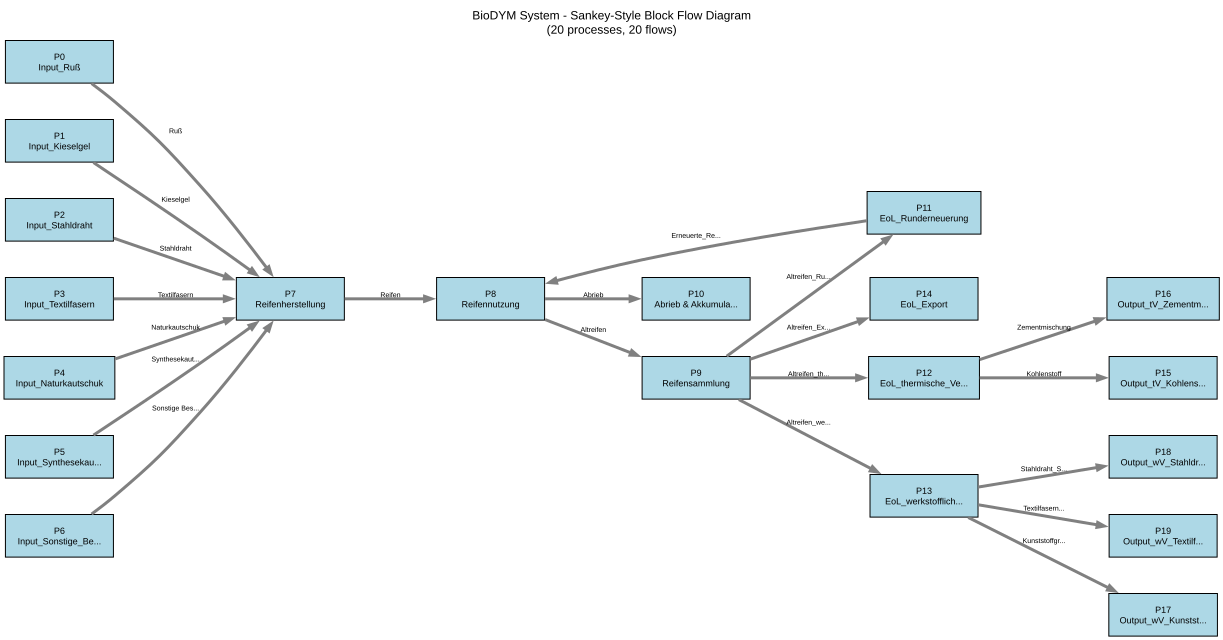

✅ Graphviz chart created successfully!


In [42]:
# ## 2.4 System Flow Diagram (Graphviz)
print(f"\n{Icons.ARROW} System Flow Diagram (Graphviz)")
try:
    from plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style

    # Get the required dataframes from the loaded data
    processes_data = all_excel_data["2_1_Definition_Processes"]
    flows_data = all_excel_data["1_1_Definition_Flows"]

    # Generate and display the chart
    dot_chart = plot_graphviz_flow_chart_sankey_style(processes_data, flows_data)
    if dot_chart:
        display(dot_chart)
        print(format_success("Graphviz chart created successfully!"))
except ImportError:
    print(f"{Icons.WARNING} Graphviz library not found. Skipping this plot.")
except Exception as e:
    print(f"{Icons.WARNING} Graphviz chart failed: {e}")

In [43]:
# ## 2.5 Flow Composition Validation
print(f"\n{Icons.ARROW} Flow Composition Validation")
print("   • Validates completeness of element composition across all flows")
print("   • Interactive visualization of flow composition hierarchy")
plot_flow_composition(mfa_results_baseline)


→ Flow Composition Validation
   • Validates completeness of element composition across all flows
   • Interactive visualization of flow composition hierarchy


HTML(value='')

FigureWidget({
    'data': [{'hovertemplate': '<b>%{y}</b><br>Remaining DM: %{x:.1f}%<extra></extra>',
              'marker': {'color': '#66afff', 'line': {'color': '#212529', 'width': 0.5}},
              'name': 'Remaining DM',
              'orientation': 'h',
              'type': 'bar',
              'uid': '5e069b91-01f5-41fd-a4df-95981f58237a',
              'x': [5.0, 95.0, 99.0, 35.0, 11.999999999999995, 10.999999999999995,
                    30.988235294117644, 30.98823529411764, 30.98823529411764,
                    30.988235294117644, 30.988235294117644, 30.988235294117654,
                    30.98823529411765, 24.08705882352941, 93.09882352941176,
                    32.671449067431844, 92.33202614379086, -45.691503267973836,
                    30.988235294117644, 30.98823529411764, 30.98823529411764],
              'y': [F_00_07, F_01_07, F_02_07, F_03_07, F_04_07, F_05_07, F_07_08,
                    F_08_09, F_08_10, F_09_11, F_09_12, F_09_13, F_09_14, F_12_15,
  

In [44]:
# Export flow composition data
from plotting.composition_export import export_flow_composition

In [45]:
export_path = "01_data/02_output/composition_export/flow_composition.xlsx"
export_flow_composition(mfa_results_baseline, export_path)


--> Flow composition data successfully exported to 01_data/02_output/composition_export/flow_composition.xlsx


# 3. Visualization

In [46]:
print(format_header("VISUALIZATION (BASELINE)"))


VISUALIZATION (BASELINE)



## 3.1 Sankey Diagrams

In [47]:
# ### 3.1.1 Traditional Sankey (Auto-Layout)
print(f"\n{Icons.ARROW} Traditional Sankey Diagram (Auto-Layout)")
print("   • Single element selection with dropdown")
print("   • Automatic node positioning via topological sort")
print("   • Interactive filtering by year, process, and flow threshold")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


→ Traditional Sankey Diagram (Auto-Layout)
   • Single element selection with dropdown
   • Automatic node positioning via topological sort
   • Interactive filtering by year, process, and flow threshold


In [48]:
# ### 3.1.2 Enhanced Sankey (Custom Positioning)
print(f"\n{Icons.ARROW} Enhanced Sankey Diagram (Custom Positioning)")
print("   • Custom node positioning from Excel configuration")
print("   • Toggle between Custom and Auto-Layout modes")
print("   • Element-specific layouts for showing hierarchy")
print("   • Special process highlighting (DSM, FOMP)")
plotting.plot_enhanced_sankey(
    mfa_results_baseline,
    dsm_params=dsm_params,
    fomp_params=fomp_params,
    visualization_config_path=input_file,
)


→ Enhanced Sankey Diagram (Custom Positioning)
   • Custom node positioning from Excel configuration
   • Toggle between Custom and Auto-Layout modes
   • Element-specific layouts for showing hierarchy
   • Special process highlighting (DSM, FOMP)
Loading visualization configuration from Excel...
   🗑️  Temp file cleaned up: C:\Users\Johannes\AppData\Local\Temp\BioDYM_temp_qs6d9ler.xlsm
  Loaded and processed 6_1_Visualization_Processes
   🗑️  Temp file cleaned up: C:\Users\Johannes\AppData\Local\Temp\BioDYM_temp_4q94yvcc.xlsm
  Loaded 6_2_Visualization_Flows
   🗑️  Temp file cleaned up: C:\Users\Johannes\AppData\Local\Temp\BioDYM_temp_2b7txmba.xlsm
  Loaded 6_3_Layout_Configuration
Visualization configuration loaded successfully


In [49]:
# ## 3.2 Additional Visualizations
print(f"\n{Icons.ARROW} Additional Visualizations")


→ Additional Visualizations


In [50]:
# ### 3.2.1 Core System Dynamics
print(f"\n{Icons.VISUALIZATION} Core System Dynamics:")
print("   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)")
print("   • Flow Dynamics: Multi-flow time series analysis")
print("   • Stock Analysis: Interactive bar charts with time slider")


📊 Core System Dynamics:
   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)
   • Flow Dynamics: Multi-flow time series analysis
   • Stock Analysis: Interactive bar charts with time slider


In [51]:
# Process Dynamics - 3-panel view showing inflow, stock, and outflow for selected processes
print(f"\n{Icons.MFA} Process Dynamics Analysis:")
plotting.plot_process_dynamics(
    mfa_results_baseline, all_excel_data["2_1_Definition_Processes"]
)


🔄 Process Dynamics Analysis:


FigureWidget({
    'data': [{'line': {'color': '#00C851', 'width': 2},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': 'd85ed38d-642f-42be-9f6d-4e98f319c59b',
              'x': [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
                    2017, 2018, 2019, 2020, 2021, 2022, 2023],
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'line': {'color': '#6F42C1', 'width': 2},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Stock',
              'type': 'scatter',
              'uid': '3c2a1885-3203-4843-9211-e90e6c8fde4c',
              'x': [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
                    2017, 2018, 2019, 2020, 2021, 20

In [52]:
# Flow Dynamics - Multi-flow time series with element selection
print(f"\n{Icons.SANKEY} Flow Dynamics Analysis:")
plotting.plot_flow_dynamics(mfa_results_baseline)


🌊 Flow Dynamics Analysis:


FigureWidget({
    'data': [{'line': {'width': 2},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'F_00_07',
              'type': 'scatter',
              'uid': 'f9ae1cf8-4819-4264-bd98-f96f81e4d282',
              'x': [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
                    2017, 2018, 2019, 2020, 2021, 2022, 2023],
              'y': {'bdata': ('AAAAAGDt60AzMzMz9zACQQAAAAAA+O' ... 'AAwt5AAAAAAAAf30AAAAAAAH3dQA=='),
                    'dtype': 'f8'}}],
    'layout': {'barmode': 'overlay',
               'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10}},
               'margin': {'b': 100, 'l': 100, 'r':

In [53]:
# Stock Bar Chart - Interactive stock levels with time slider
print(f"\n{Icons.BAR_CHART} Stock Levels Analysis:")
plotting.plot_stock_bar_chart(
    mfa_results_baseline, title="Stock Levels Over Time (Baseline)"
)


📈 Stock Levels Analysis:


interactive(children=(IntSlider(value=2007, description='Year', max=2023, min=2007), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': 'cdd895f2-d216-4ea7-a300-d63bebcd2827',
              'x': array(['Reifennutzung', 'Abrieb & Akkumulation in der Umwelt'], dtype=object),
              'y': {'bdata': 'AAAAAICELkEAAAAAAAAAAA==', 'dtype': 'f8'}}],
    'layout': {'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10}},
               'margin': {'b': 100, 'l': 100, 'r': 50, 't': 100},
               'paper_bgcolor': '#FFFFFF',
               'plot_bgcolor': '#FFFFFF',
               'showlegend': False,
               't

In [54]:
# System Stock Composition - Individual process stocks over time
print(f"\n{Icons.BAR_CHART} Individual Process Stocks Analysis:")
print("   • Individual process stocks over time")
print("   • Shows each process stock separately")
print("   • Element selection and bar/line chart options")
plotting.plot_system_stock_composition(mfa_results_baseline)


📈 Individual Process Stocks Analysis:
   • Individual process stocks over time
   • Shows each process stock separately
   • Element selection and bar/line chart options


FigureWidget({
    'data': [], 'layout': {'template': '...'}
})

In [55]:
# ### 3.2.2 Specialized Process Analysis (if applicable)
print(f"\n{Icons.VISUALIZATION} Specialized Process Analysis:")


📊 Specialized Process Analysis:


In [56]:
# DSM Stock Details - Detailed DSM stock evolution (if DSM processes exist)
if dsm_params and dsm_details_baseline:
    print(f"\n{Icons.DSM} DSM Stock Evolution Analysis:")
    print("   • Individual and cumulative stock views")
    print("   • Lifetime analysis and category breakdown")
    plotting.plot_dsm_stock_details(
        mfa_results_baseline, dsm_params, dsm_details_baseline
    )

    print(f"\n{Icons.MFA} DSM Process Dynamics Analysis:")
    print("   • Three-panel view: Input, Stock, Output")
    print("   • Stacked flows by element (Material, WC, DM, CC)")
    print("   • Dynamic material composition for DSM processes")
    plotting.plot_dsm_process_dynamics(
        mfa_results_baseline, dsm_params, dsm_details_baseline
    )
else:
    print(f"   {Icons.INFO} No DSM processes found - skipping DSM analysis")


🏗️ DSM Stock Evolution Analysis:
   • Individual and cumulative stock views
   • Lifetime analysis and category breakdown


FigureWidget({
    'data': [{'fill': 'tozeroy',
              'hovertemplate': '<b>Initial Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#ff7f0e', 'dash': 'dash', 'width': 0.5},
              'mode': 'lines',
              'name': 'Initial Stock (Decaying)',
              'stackgroup': 'one',
              'type': 'scatter',
              'uid': '80b8bf1e-412c-4209-96a8-a20347d22bc8',
              'x': [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
                    2017, 2018, 2019, 2020, 2021, 2022, 2023],
              'y': {'bdata': ('AAAAAICELkGvobyG8rIpQfLzaIwqpC' ... 'B/BPZAQrwVUYaK8kDbqAmWJTrvQA=='),
                    'dtype': 'f8'}},
             {'fill': 'tonexty',
              'hovertemplate': '<b>Standarfahrer</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'width': 0.5},
              'mode': 'lines',
              'name': 'Standarfahrer',
              'stackgroup': 'one',



🔄 DSM Process Dynamics Analysis:
   • Three-panel view: Input, Stock, Output
   • Stacked flows by element (Material, WC, DM, CC)
   • Dynamic material composition for DSM processes


FigureWidget({
    'data': [{'fill': 'tozeroy',
              'hovertemplate': '<b>F_07_08</b><br>Year: %{x}<br>material: %{y:.2e} Mg<extra></extra>',
              'line': {'width': 0.5},
              'mode': 'lines',
              'name': 'F_07_08',
              'stackgroup': 'input',
              'type': 'scatter',
              'uid': '4d1f7ae7-38a7-4b33-8d73-05ffc9274879',
              'x': [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
                    2017, 2018, 2019, 2020, 2021, 2022, 2023],
              'xaxis': 'x',
              'y': {'bdata': ('AAAAACTIE0E9CtcjjuUzQQAAAABApx' ... 'AY0hBBAAAAAPQEEUEAAAAAXCAQQQ=='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'fill': 'tonexty',
              'hovertemplate': '<b>F_11_08</b><br>Year: %{x}<br>material: %{y:.2e} Mg<extra></extra>',
              'line': {'width': 0.5},
              'mode': 'lines',
              'name': 'F_11_08',
              'stackgroup': 'input',
   

In [57]:
# FOMP Analysis - FOMP mineralization analysis (if FOMP processes exist)
if fomp_params:
    print(f"\n{Icons.FOMP} FOMP Mineralization Analysis:")
    print("   • Organic matter accumulation and mineralization")
    print("   • Annual vs cumulative flow analysis")
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)

    # FOMP Process Dynamics - Three-panel view of FOMP processes
    print(f"\n{Icons.MFA} FOMP Process Dynamics:")
    print(
        "   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)"
    )
    print("   • Decay rates displayed as percentages")
    print("   • Water Content (WC) excluded from mineralization")
    plotting.plot_fomp_dynamics(mfa_results_baseline, fomp_params)
else:
    print(f"   {Icons.INFO} No FOMP processes found - skipping FOMP analysis")

   ℹ️ No FOMP processes found - skipping FOMP analysis


# 4. Scenario & Uncertainty Manager

In [58]:
# ## 4.1 Scenario Analysis & Comparison
print(format_header("SCENARIO ANALYSIS"))


SCENARIO ANALYSIS



In [59]:
# Import the new scenario engine
from engine import scenario_engine

In [60]:
# Run scenario analysis using the new engine
all_scenario_results, scenario_definitions = scenario_engine.run_scenario_analysis(
    config_obj=config_obj,
    mfa_system_configured=mfa_system_configured,
    all_excel_data=all_excel_data,
    dsm_params=dsm_params,
    fomp_params=fomp_params,
    flow_tc_map=flow_tc_map,
    process_logic_map=process_logic_map,
)


🎭 SCENARIO ANALYSIS ENGINE
Found 4 scenarios to run: ['Scenario 1', 'DPP_Scenario', 'Scenario 3', 'Scenario 4']
--> Loading scenario definitions from sheet '5_1_Scenario_Manager'...
--> Successfully loaded 0 scenario(s).

🎭 RUNNING SCENARIO: 'Scenario 1'
⚠️ WARNING: Scenario 'Scenario 1' not found in '5_1_Scenario_Manager' sheet! Skipping.

🎭 RUNNING SCENARIO: 'DPP_Scenario'
⚠️ WARNING: Scenario 'DPP_Scenario' not found in '5_1_Scenario_Manager' sheet! Skipping.

🎭 RUNNING SCENARIO: 'Scenario 3'
⚠️ WARNING: Scenario 'Scenario 3' not found in '5_1_Scenario_Manager' sheet! Skipping.

🎭 RUNNING SCENARIO: 'Scenario 4'
⚠️ WARNING: Scenario 'Scenario 4' not found in '5_1_Scenario_Manager' sheet! Skipping.

✅ Scenario analysis completed: 0 scenarios processed


In [61]:
# Generate visualizations if scenarios were run
if all_scenario_results:
    scenario_engine.generate_scenario_comparison_visualizations(
        baseline_results=mfa_results_baseline,
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions,
    )

    # Export scenario results
    scenario_engine.export_scenario_results(
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions,
    )
else:
    print(f"{Icons.INFO} No scenarios were processed.")

ℹ️ No scenarios were processed.


In [62]:
# ## 4.2 Monte Carlo Analysis
print(format_header("MONTE CARLO SIMULATION (BASELINE)", level=2))


MONTE CARLO SIMULATION (BASELINE)



In [63]:
if config_obj.RUN_MONTE_CARLO and "4_1_Uncertainty_Parameters" in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from plotting.monte_carlo import (
            plot_interactive_mc_multiple_histograms,
            plot_interactive_tornado,
            plot_interactive_mc_paths,
            plot_interactive_mc_stock_comparison,
        )

        mc_results = run_mc_simulation(
            mfa_system_configured,
            input_data,
            dsm_params,
            fomp_params,
            config_obj,
            process_logic_map=process_logic_map,
            flow_tc_map=flow_tc_map,
        )

        if mc_results is not None and not mc_results.empty:
            print(format_success("Monte Carlo simulation completed for baseline."))

            # --- Export MC Results ---
            print(f"\n{Icons.EXPORT} Exporting Monte Carlo results...")
            from datetime import datetime

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            mc_output_path = (
                f"01_data/02_output/mc_output/mc_results_detailed_{timestamp}.xlsx"
            )
            try:
                mc_results.to_excel(mc_output_path, index=False)
                print(
                    format_success(
                        f"Monte Carlo results successfully exported to: {mc_output_path}"
                    )
                )
            except Exception as export_error:
                print(
                    f"{Icons.WARNING} Could not export Monte Carlo results: {export_error}"
                )
            # -------------------------

            print(f"\n{Icons.VISUALIZATION} Monte Carlo Analysis Visualizations:")
            print(
                "   • Multiple Distribution Histograms: Interactively select and view histograms for multiple stocks."
            )
            print(
                "   • Sensitivity Tornado Plot: Identify which parameters most influence outcomes."
            )
            print(
                "   • Simulation Paths: Visualize the trajectories of all Monte Carlo runs."
            )
            print(
                "   • Stock Comparison: Compare distributions of several stocks in one plot."
            )

            # This new function allows selecting multiple histograms, making the old single one redundant.
            plot_interactive_mc_multiple_histograms(mc_results, mfa_results_baseline)

            plot_interactive_tornado(mc_results)
            plot_interactive_mc_paths(mc_results, mfa_results_baseline)
            plot_interactive_mc_stock_comparison(mc_results, mfa_results_baseline)

    except Exception as e:
        print(f"{Icons.WARNING} Monte Carlo simulation failed: {e}")
        import traceback

        traceback.print_exc()
else:
    print(
        f"{Icons.INFO} Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping."
    )

ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.


# 5. Data Export

In [64]:
print(format_header("EXPORTING BASELINE RESULTS"))


EXPORTING BASELINE RESULTS



## 5.1 KPI Dashboard and Export

In [65]:
kpi_output_path = "01_data/02_output/kpi_dashboard/system_kpis.xlsx"
print(format_step(Icons.EXPORT, "5.1", "Generating KPI Dashboard..."))
kpi_dashboard.generate_kpi_dashboard(
    mfa_results_baseline, process_logic_map, kpi_output_path
)

  💾 [5.1] Generating KPI Dashboard...

📊 KEY PERFORMANCE INDICATOR (KPI) DASHBOARD

--- KPIs for Element: material ---
            Metric Unit First Year (2007)  Last Year (2023) 
       Total Input Mg/a          324105.00         264215.00
      Total Output Mg/a          154032.41         318080.85
  Net Stock Change Mg/a          249037.67          15398.80
Mass Balance Error Mg/a        -78965.0859       -69264.6461
Critical Deviation    %           -24.3640          -26.2153

----------------------------------------
System Throughput (material):
  - First Year: 946055.61 Mg/a
  - Last Year:  1323190.31 Mg/a
  - Average:    1461341.14 Mg/a
----------------------------------------

--- KPIs for Element: DM ---
            Metric Unit First Year (2007)  Last Year (2023) 
       Total Input Mg/a          324105.00         264215.00
      Total Output Mg/a          154032.41         318080.85
  Net Stock Change Mg/a          249037.67          15398.80
Mass Balance Error Mg/a        -7

In [66]:
print(format_step(Icons.EXPORT, "5.2", "Exporting baseline results..."))
output_file = "01_data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(
    mfa_results_baseline, output_file, input_file_path=input_file
)
print(format_success(f"Baseline results exported to: {output_file}"))

  💾 [5.2] Exporting baseline results...
--> Exporting results to '01_data/02_output/results_scientific_baseline.xlsx'...
✅ Results successfully exported to 01_data/02_output/results_scientific_baseline.xlsx
✅ Baseline results exported to: 01_data/02_output/results_scientific_baseline.xlsx


In [67]:
print(format_header("ANALYSIS COMPLETE"))


ANALYSIS COMPLETE

